# CastMe forget sets and canonical full retraining

## 1. Introduction

This notebook constructs five operationally distinct personal-data deletion requests from the frozen seed-42 baseline partitions. The conditions represent person-based, distributed submission-level, provider/relationship-based, purpose/project-based and time/retention-based deletion. They are synthetic experimental scenarios, not claims about a particular legal right or regulatory compliance.

Each scenario is evaluated independently from the same Original Model and split. Full retraining fits a fresh seed-42 MLP and a scenario-specific preprocessor on retained rows only, providing the deterministic “never trained on these rows” reference for later approximate methods.


## 2. Imports, Reproducibility and Paths

### 2.1 Import Libraries

Imports are kept separate from reproducibility and path configuration.

In [1]:
# imports
from __future__ import annotations

import copy
import hashlib
import json
import platform
import random
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.exceptions import InconsistentVersionWarning
from sklearn.metrics import (
    accuracy_score, average_precision_score, confusion_matrix, f1_score, log_loss, precision_score,
    recall_score, roc_auc_score, roc_curve,
)
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


### 2.2 Reproducibility, Device and Paths

The fixed baseline seed and approved CastMe paths are established before any data
are loaded. The device changes execution hardware only, not the experiment design.

In [2]:
# find the main code folder
def locate_code_root(start_path: Path) -> Path:
    "Return the project code directory containing the cleaned CastMe CSV."
    for candidate in [start_path, *start_path.parents]:
        direct = candidate / "data/processed/castme/castme_auditions_clean.csv"
        nested = candidate / "code/data/processed/castme/castme_auditions_clean.csv"
        if direct.is_file(): return candidate
        if nested.is_file(): return candidate / "code"
    raise FileNotFoundError("Could not locate the cleaned CastMe CSV.")

def sha256(file_path: Path) -> str:
    return hashlib.sha256(file_path.read_bytes()).hexdigest()

def array_hash(values: np.ndarray) -> str:
    return hashlib.sha256(np.asarray(values, dtype=np.int64).tobytes()).hexdigest()

# set seed
RANDOM_SEED = 42
CODE_ROOT = locate_code_root(Path.cwd().resolve())
RAW_DATA_PATH = CODE_ROOT / "data/raw/castme/castme_auditions.csv"
CLEAN_DATA_PATH = CODE_ROOT / "data/processed/castme/castme_auditions_clean.csv"
BASELINE_MODEL_PATH = CODE_ROOT / "models/castme/castme_baseline_mlp.pt"
BASELINE_PREPROCESSOR_PATH = CODE_ROOT / "models/castme/castme_preprocessor.joblib"
BASELINE_MANIFEST_PATH = CODE_ROOT / "results/CastMe/configuration/baseline_manifest.json"
BASELINE_METRICS_PATH = CODE_ROOT / "results/CastMe/metrics/baseline_metrics.csv"
FULL_MODEL_ROOT = CODE_ROOT / "models/castme/full_retraining"
FULL_RESULTS_ROOT = CODE_ROOT / "results/CastMe/full_retraining"
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: mps


### 2.3 Frozen Deletion Scenario Configuration

The actor and retention cutoff were selected once using the seed-42 training metadata, then frozen as literals. Submission withdrawals are recorded audit metadata rather than a generic precomputed forget-set label.


In [3]:
# Fixed identifiers and date used to construct the deletion requests.
ACTOR_IDENTIFIER = "A034"
MANAGER_IDENTIFIER = "M20"
FILM_IDENTIFIER = "F50"
RETENTION_CUTOFF = "2021-09-20"


## 3. Load Baseline Artifacts and Saved Split

The original baseline is read only. Its hashes, seed, and split procedure anchor
the full-retraining comparison to the approved Original Model.

In [4]:
# Record hashes of the baseline files so later checks can prove they were unchanged.
baseline_manifest = json.loads(BASELINE_MANIFEST_PATH.read_text())
BASELINE_ARTIFACTS = [
    CODE_ROOT / "notebooks/CastMe/01_castme_baseline.ipynb", BASELINE_MODEL_PATH,
    BASELINE_PREPROCESSOR_PATH, BASELINE_METRICS_PATH, BASELINE_MANIFEST_PATH,
    CODE_ROOT / "results/CastMe/tables/training_history.csv",
    CODE_ROOT / "results/CastMe/figures/confusion_matrix.png",
    CODE_ROOT / "results/CastMe/figures/roc_curve.png",
    CODE_ROOT / "results/CastMe/figures/loss_curve.png",
]
# Include the saved train, validation and test split files.
for split in baseline_manifest["split_artifacts"].values():
    BASELINE_ARTIFACTS.extend([CODE_ROOT / split["index_path"], CODE_ROOT / split["audition_id_path"]])
BASELINE_HASHES = {str(path.relative_to(CODE_ROOT)): sha256(path) for path in BASELINE_ARTIFACTS}
RAW_CSV_HASH, CLEANED_CSV_HASH = sha256(RAW_DATA_PATH), sha256(CLEAN_DATA_PATH)

# Load the dataset and saved baseline artifacts.
clean_df = pd.read_csv(CLEAN_DATA_PATH)
baseline_checkpoint = torch.load(BASELINE_MODEL_PATH, map_location="cpu", weights_only=False)
# Suppress the expected version warning; schema checks below still validate the preprocessor.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", InconsistentVersionWarning)
    baseline_preprocessor = joblib.load(BASELINE_PREPROCESSOR_PATH)
baseline_metrics = pd.read_csv(BASELINE_METRICS_PATH)

# Recover the original model configuration.
FEATURE_COLUMNS = baseline_checkpoint["feature_columns"]
CONTINUOUS_COLUMNS = baseline_checkpoint["continuous_columns"]
BINARY_COLUMNS = baseline_checkpoint["binary_columns"]
IDENTIFIER_COLUMNS = ["audition_id", "actor_id", "manager_id", "film_id", "role_id", "audition_round"]
AUDIT_METADATA_COLUMNS = ["audition_date", "withdrawal_requested"]
METADATA_COLUMNS, TARGET_COLUMN = IDENTIFIER_COLUMNS + AUDIT_METADATA_COLUMNS, "callback"
THRESHOLD = float(baseline_checkpoint["selected_threshold"])
ARCHITECTURE, HYPERPARAMETERS = baseline_checkpoint["architecture"], baseline_checkpoint["training_hyperparameters"]

# Confirm that the dataset, model and manifest agree.
assert baseline_manifest["seed"] == baseline_checkpoint["seed"] == RANDOM_SEED
assert baseline_manifest["raw_dataset_hash"] == baseline_checkpoint["raw_csv_sha256"] == RAW_CSV_HASH
assert baseline_manifest["processed_dataset_hash"] == baseline_checkpoint["cleaned_csv_sha256"] == CLEANED_CSV_HASH
assert clean_df.shape == (60_000, 19) and not clean_df.isna().any().any() and "split" not in clean_df
assert len(FEATURE_COLUMNS) == 10 and set(AUDIT_METADATA_COLUMNS).isdisjoint(FEATURE_COLUMNS)
assert baseline_checkpoint["excluded_metadata_columns"] == METADATA_COLUMNS
display(baseline_metrics.style.hide(axis="index").format(precision=4))


model,split,threshold_decision,threshold,accuracy,precision,recall,f1,specificity,balanced_accuracy,auroc,pr_auc,brier_score,binary_cross_entropy,confusion_matrix
mlp,validation,validation_selected,0.3200,0.6782,0.5372,0.7858,0.6382,0.6174,0.7016,0.7725,0.6387,0.1828,0.5425,"[[3550, 2200], [696, 2554]]"
mlp,test,threshold_0_50,0.5000,0.7190,0.6278,0.5442,0.5830,0.8178,0.6810,0.7686,0.6264,0.1843,0.5456,"[[4703, 1048], [1481, 1768]]"
mlp,test,previous_fixed_baseline,0.4000,0.7052,0.5774,0.6839,0.6262,0.7173,0.7006,0.7686,0.6264,0.1843,0.5456,"[[4125, 1626], [1027, 2222]]"
mlp,test,validation_selected,0.3200,0.6758,0.5350,0.7787,0.6342,0.6176,0.6982,0.7686,0.6264,0.1843,0.5456,"[[3552, 2199], [719, 2530]]"


### 3.1 Load the Saved Baseline Split

The exact seed-42 stratified index arrays and audition identities are loaded from Notebook 01 and verified against its manifest. Forget sets are subsets of those saved training rows; no split is reconstructed.


In [5]:
# Separate model features, target values and audit metadata.
features = clean_df[FEATURE_COLUMNS].copy()
target = clean_df[TARGET_COLUMN].copy()
metadata = clean_df[METADATA_COLUMNS].copy()
metadata["audition_date"] = pd.to_datetime(metadata["audition_date"], format="%Y-%m-%d", errors="raise")
assert metadata["withdrawal_requested"].dtype == bool

# Load the exact baseline splits instead of creating new ones.
loaded_splits, loaded_ids = {}, {}
for name, artifact in baseline_manifest["split_artifacts"].items():
    index_path, id_path = CODE_ROOT / artifact["index_path"], CODE_ROOT / artifact["audition_id_path"]
    
    # Confirm that the saved split files have not changed.
    assert sha256(index_path) == artifact["index_sha256"]
    assert sha256(id_path) == artifact["audition_id_sha256"]
    loaded_splits[name] = np.load(index_path, allow_pickle=False)
    loaded_ids[name] = np.load(id_path, allow_pickle=False)
    
    # Confirm that each row position still matches the correct audition ID.
    assert len(loaded_splits[name]) == artifact["row_count"]
    assert np.array_equal(loaded_ids[name], metadata.loc[loaded_splits[name], "audition_id"].astype(str).to_numpy(dtype="U"))
train_indices, validation_indices, test_indices = (loaded_splits[name] for name in ["train", "validation", "test"])

# Confirm that the splits have the correct sizes, do not overlap and include every row.
split_indices = loaded_splits
split_sets = {name: set(values.tolist()) for name, values in split_indices.items()}
assert [len(train_indices), len(validation_indices), len(test_indices)] == [42_000, 9_000, 9_000]
assert not split_sets["train"] & split_sets["validation"]
assert not split_sets["train"] & split_sets["test"]
assert not split_sets["validation"] & split_sets["test"]
assert set.union(*split_sets.values()) == set(clean_df.index)


In [6]:
# Use the saved row indices to create the feature, target and metadata splits.
train_features, validation_features, test_features = (features.loc[split_indices[name]] for name in split_indices)
train_target, validation_target, test_target = (target.loc[split_indices[name]] for name in split_indices)
train_metadata, validation_metadata, test_metadata = (metadata.loc[split_indices[name]] for name in split_indices)

# Record the callback rate in the original training set.
overall_callback_rate = float(train_target.mean())

# Summarise the size and callback rate of each split.
split_summary = pd.DataFrame([
    {"split": name, "rows": len(index), "callback_rate": target.loc[index].mean()}
    for name, index in split_indices.items()
])
display(split_summary.style.hide(axis="index").format({"callback_rate": "{:.2%}"}))


split,rows,callback_rate
train,42000,36.10%
validation,9000,36.11%
test,9000,36.10%


## 4. Configure and Profile CastMe Deletion Scenarios

Profiles describe the manually configured scenarios; they do not choose the
identifiers. All profile statistics use training rows only, avoiding selection
based on validation or test outcomes.

In [7]:
# Record the training-set feature averages and standard deviations.
# These are used to compare each deletion group with the full training set.
overall_feature_mean = train_features.mean()
overall_feature_std = train_features.std(ddof=0).replace(0, 1.0)


def scenario_mask(frame: pd.DataFrame, scenario: dict[str, object]) -> pd.Series:
    # Evaluate one frozen deletion condition against partition metadata.
    if scenario["rule_type"] == "equals":
        return frame[scenario["column"]].eq(scenario["identifier"])
    if scenario["rule_type"] == "boolean_true":
        return frame[scenario["column"]].eq(True)
    if scenario["rule_type"] == "date_before":
        return frame[scenario["column"]].lt(pd.Timestamp(scenario["identifier"]))
    raise ValueError(f"Unsupported rule type: {scenario['rule_type']}")


def profile_mask(mask: pd.Series) -> dict[str, object]:
    # Summarise size, outcomes, entities and standardised feature distance.
    subset_features = train_features.loc[mask]
    subset_metadata = train_metadata.loc[mask]
    subset_target = train_target.loc[mask]
    
    # Standardise feature differences so features with different scales are comparable.
    difference = (subset_features.mean() - overall_feature_mean) / overall_feature_std
    return {
        "training_rows": int(mask.sum()),
        "training_percentage": float(mask.mean()),
        "callback_count": int(subset_target.sum()),
        "callback_rate": float(subset_target.mean()),
        "actor_count": int(subset_metadata["actor_id"].nunique()),
        "manager_count": int(subset_metadata["manager_id"].nunique()),
        "film_count": int(subset_metadata["film_id"].nunique()),
        "role_count": int(subset_metadata["role_id"].nunique()),
        "date_count": int(subset_metadata["audition_date"].nunique()),
        "profile_distance": float(np.sqrt((difference**2).sum())),
    }


### 4.1 Validate and Profile the Configured Identifiers

Configured values must be zero-padded identifiers present in baseline training
data. The displayed profiles provide context about size, class balance, entity
coverage, and similarity to the overall training population.

In [8]:
# Build actor profiles using metadata only; callback outcomes are not considered.
actor_profiles = train_metadata.groupby("actor_id").agg(
    training_rows=("audition_id", "size"), manager_id=("manager_id", "first"),
    film_count=("film_id", "nunique"), role_count=("role_id", "nunique"),
)
actor_profiles["training_percentage"] = actor_profiles["training_rows"] / len(train_metadata)
actor_profiles["f50_share"] = train_metadata["film_id"].eq(FILM_IDENTIFIER).groupby(train_metadata["actor_id"]).mean()

# Keep actors near 1% of the training set who meet the coverage requirements.
eligible_actors = actor_profiles.loc[
    actor_profiles["training_percentage"].sub(0.01).abs().le(0.0025)
    & actor_profiles["film_count"].ge(10) & actor_profiles["role_count"].ge(50)
    & actor_profiles["f50_share"].lt(1.0) & actor_profiles["manager_id"].ne(MANAGER_IDENTIFIER)
].copy()

# Select the actor closest to 1%; actor ID resolves an exact tie.
eligible_actors["distance_to_one_percent"] = eligible_actors["training_percentage"].sub(0.01).abs()
selected = eligible_actors.reset_index().sort_values(["distance_to_one_percent", "actor_id"]).iloc[0]

# Confirm the fixed scenario identifiers.
assert selected["actor_id"] == ACTOR_IDENTIFIER
selected_actor_manager = str(selected["manager_id"])
assert MANAGER_IDENTIFIER in set(train_metadata["manager_id"])
assert FILM_IDENTIFIER in set(train_metadata["film_id"])
assert pd.Timestamp(RETENTION_CUTOFF) == pd.Timestamp("2021-09-20")

# Display the selected actor's training-data profile.
actor_selection_summary = pd.DataFrame([{
    "selected_actor": ACTOR_IDENTIFIER, "training_rows": int(selected["training_rows"]),
    "training_percentage": float(selected["training_percentage"]), "manager_id": selected["manager_id"],
    "film_count": int(selected["film_count"]), "role_count": int(selected["role_count"]),
    "f50_share": float(selected["f50_share"]),
}])
display(actor_selection_summary.style.hide(axis="index").format({"training_percentage": "{:.2%}", "f50_share": "{:.2%}"}))


selected_actor,training_rows,training_percentage,manager_id,film_count,role_count,f50_share
A034,415,0.99%,M07,49,415,0.00%


### 4.2 Configure Scenario Definitions

The scenario dictionary uses only identifiers explicitly configured in Section 2.3.

In [9]:
# Define each deletion request using metadata only.
SCENARIOS = {
    "s1_actor_withdrawal": {
        "display_name": "Actor withdrawal — 1%", "rule_type": "equals",
        "column": "actor_id", "identifier": ACTOR_IDENTIFIER,
        "requested_percentage": 0.01,
        "subset_rule": f"actor_id == '{ACTOR_IDENTIFIER}'",
        "reason": "An individual asks CastMe to delete all audition submissions and associated personal data.",
    },
    "s2_submission_withdrawal": {
        "display_name": "Submission withdrawal — 5%", "rule_type": "boolean_true",
        "column": "withdrawal_requested", "identifier": "True",
        "requested_percentage": 0.05,
        "subset_rule": "withdrawal_requested == True",
        "reason": "Different actors withdraw specific submissions or self-tapes without deleting their accounts.",
    },
    "s3_agency_withdrawal": {
        "display_name": "Agency withdrawal — 10%", "rule_type": "equals",
        "column": "manager_id", "identifier": MANAGER_IDENTIFIER,
        "requested_percentage": 0.10,
        "subset_rule": f"manager_id == '{MANAGER_IDENTIFIER}'",
        "reason": "An agency ends its agreement, requiring removal of the personal audition data it supplied.",
    },
    "s4_project_closure": {
        "display_name": "Project closure — 15%", "rule_type": "equals",
        "column": "film_id", "identifier": FILM_IDENTIFIER,
        "requested_percentage": 0.15,
        "subset_rule": f"film_id == '{FILM_IDENTIFIER}'",
        "reason": "The casting purpose has ended, so personal audition data collected for the project is no longer required.",
    },
    "s5_retention_expiry": {
        "display_name": "Retention expiry — 15%", "rule_type": "date_before",
        "column": "audition_date", "identifier": RETENTION_CUTOFF,
        "requested_percentage": 0.15,
        "subset_rule": f"audition_date < '{RETENTION_CUTOFF}'",
        "reason": "Older audition records have exceeded CastMe's defined retention period.",
    },
}
# Confirm that the scenarios remain in the required order.
assert list(SCENARIOS) == ["s1_actor_withdrawal", "s2_submission_withdrawal",
                            "s3_agency_withdrawal", "s4_project_closure", "s5_retention_expiry"]


### 4.3 Display Configured Scenario Profiles

These rows describe the configured groups; they are not an automatic selection rule.

In [10]:
# Apply each deletion rule and record the characteristics of its deleted records.
SCENARIO_PROFILES = {}
configured_rows = []
for scenario_name, scenario in SCENARIOS.items():
    
    # Find the training rows covered by this deletion request.
    mask = scenario_mask(train_metadata, scenario)
    
    # Summarise the size, callback rate, entities and feature profile.
    profile = profile_mask(mask)
    assert profile["training_rows"] > 0
    
    # Store the profile for use during full retraining.
    SCENARIO_PROFILES[scenario_name] = profile
    
    # Prepare a readable row for the scenario summary table.
    configured_rows.append({
        "scenario": scenario_name,
        "display_name": scenario["display_name"],
        "subset_rule": scenario["subset_rule"],
        "deletion_reason": scenario["reason"],
        **profile,
    })


In [11]:
# Convert the scenario profiles into a table for comparison.
configured_scenarios = pd.DataFrame(configured_rows)

# Display the size and composition of each deletion group.
display(
    configured_scenarios[[
        "scenario", "display_name", "subset_rule", "training_rows",
        "training_percentage", "callback_rate", "profile_distance",
        "actor_count", "manager_count", "film_count", "role_count", "date_count",
    ]].style.hide(axis="index").format({
        "training_percentage": "{:.2%}",
        "callback_rate": "{:.2%}",
        "profile_distance": "{:.4f}",
    })
)

# Report the fixed actor and retention-date selections.
print(f"Frozen 1% actor {ACTOR_IDENTIFIER} is managed by {selected_actor_manager}.")
print(f"Frozen retention cutoff: {RETENTION_CUTOFF}")


scenario,display_name,subset_rule,training_rows,training_percentage,callback_rate,profile_distance,actor_count,manager_count,film_count,role_count,date_count
s1_actor_withdrawal,Actor withdrawal — 1%,actor_id == 'A034',415,0.99%,18.07%,1.6180,1,1,49,415,370
s2_submission_withdrawal,Submission withdrawal — 5%,withdrawal_requested == True,2137,5.09%,37.81%,0.0578,100,20,50,619,1192
s3_agency_withdrawal,Agency withdrawal — 10%,manager_id == 'M20',4224,10.06%,32.88%,0.8949,10,1,49,600,1528
s4_project_closure,Project closure — 15%,film_id == 'F50',6289,14.97%,30.66%,0.3365,15,3,1,24,1721
s5_retention_expiry,Retention expiry — 15%,audition_date < '2021-09-20',6298,15.00%,36.58%,0.0499,99,20,50,690,262


Frozen 1% actor A034 is managed by M07.
Frozen retention cutoff: 2021-09-20


- The frozen actor is **A034**, selected deterministically from seed-42 training metadata only. It has approximately 1% of training rows, spans many films and roles, is outside manager M20, and is not contained in project F50; the submission scenario uses distributed recorded withdrawals rather than deleting whole accounts.

### 4.4 Scenario Independence and Overlap

To examine a different deletion request, change one or more identifiers in
Section 2.3 and run the notebook from the beginning. Scenario summaries,
forget/retain indices, fully retrained models, metrics, and figures will be
regenerated for the new identifiers.

## 5. Construct Forget and Retain Sets

In [12]:
# Divide the training data into deleted and retained records for each scenario.
scenario_data = {}
for scenario_name, scenario in SCENARIOS.items():

    # Identify rows to forget and keep.
    forget_mask = scenario_mask(train_metadata, scenario)
    retain_mask = ~forget_mask
    forget_indices = train_metadata.index[forget_mask].to_numpy(dtype=np.int64)
    retain_indices = train_metadata.index[retain_mask].to_numpy(dtype=np.int64)
    
    # Store the indices, features, targets and metadata for both groups.
    scenario_data[scenario_name] = {
        "forget_indices": forget_indices,
        "retain_indices": retain_indices,
        "forget_features": train_features.loc[forget_indices],
        "forget_target": train_target.loc[forget_indices],
        "forget_metadata": train_metadata.loc[forget_indices],
        "retain_features": train_features.loc[retain_indices],
        "retain_target": train_target.loc[retain_indices],
        "retain_metadata": train_metadata.loc[retain_indices],
    }


## 6. Verify Independent Scenario Construction

In [13]:
# Record the intended deletion percentage for each scenario.
TARGET_PERCENTAGES = {name: scenario["requested_percentage"] for name, scenario in SCENARIOS.items()}
for name, scenario in SCENARIOS.items():
    data = scenario_data[name]
    forget_metadata, retain_metadata = data["forget_metadata"], data["retain_metadata"]
    forget_set, retain_set = set(data["forget_indices"]), set(data["retain_indices"])
    
    # Confirm that the two groups do not overlap and cover the full training set.
    assert not forget_set & retain_set and forget_set | retain_set == set(train_indices)
    
    # Confirm that only the forget set satisfies the deletion rule.
    assert scenario_mask(forget_metadata, scenario).all()
    assert not scenario_mask(retain_metadata, scenario).any()
    
    # Check the expected structure of each deletion scenario.
    if name == "s1_actor_withdrawal":
        assert forget_metadata["actor_id"].nunique() == 1
    elif name == "s2_submission_withdrawal":
        assert forget_metadata["actor_id"].nunique() >= 90 and forget_metadata["manager_id"].nunique() >= 15
    elif name == "s3_agency_withdrawal":
        assert forget_metadata["manager_id"].nunique() == 1 and forget_metadata["actor_id"].nunique() == 10
    elif name == "s4_project_closure":
        assert forget_metadata["film_id"].nunique() == 1 and forget_metadata["role_id"].nunique() == 24
    else:
        assert forget_metadata["audition_date"].max() < pd.Timestamp(RETENTION_CUTOFF)


In [14]:
# Build a detailed summary of every deletion scenario.
scenario_summary_rows = []
for name, scenario in SCENARIOS.items():
    data, meta = scenario_data[name], scenario_data[name]["forget_metadata"]
    requested, actual = TARGET_PERCENTAGES[name], len(data["forget_indices"])
    achieved, pair_sizes = actual / len(train_indices), meta.groupby(["actor_id", "role_id"]).size()
    scenario_summary_rows.append({
        "scenario": name, "display_name": scenario["display_name"], "entity_column": scenario["column"],
        "subset_rule": scenario["subset_rule"], "deletion_reason": scenario["reason"],
        "selected_identifier": scenario["identifier"], "requested_percentage": requested,
        "achieved_percentage": achieved, "target_forget_count": int(requested * len(train_indices)),
        "actual_forget_count": actual, "forget_count": actual, "forget_percentage": achieved,
        "retain_count": len(data["retain_indices"]), "retain_percentage": len(data["retain_indices"]) / len(train_indices),
        "row_count_difference": actual - int(requested * len(train_indices)),
        "percentage_point_difference": (achieved - requested) * 100,
        "forget_callbacks": int(data["forget_target"].sum()), "forget_callback_rate": data["forget_target"].mean(),
        "retain_callbacks": int(data["retain_target"].sum()), "retain_callback_rate": data["retain_target"].mean(),
        "actors": meta["actor_id"].nunique(), "managers": meta["manager_id"].nunique(),
        "films": meta["film_id"].nunique(), "roles": meta["role_id"].nunique(),
        "dates": meta["audition_date"].nunique(), "repeated_actor_role_pairs": int((pair_sizes > 1).sum()),
        "maximum_round": int(meta["audition_round"].max()),
        "profile_distance": SCENARIO_PROFILES[name]["profile_distance"],
        
        # Hash the row indices so the exact groups can be verified later.
        "forget_index_hash": array_hash(data["forget_indices"]), "retain_index_hash": array_hash(data["retain_indices"]),
        "threshold": THRESHOLD, "threshold_label": "fixed_baseline_validation_threshold", "seed": RANDOM_SEED,
    })


In [15]:
# Convert the scenario summaries into a dataframe.
scenario_summary = pd.DataFrame(scenario_summary_rows)

# Confirm that every achieved deletion size is within 0.25 percentage points
# of its requested size.
assert scenario_summary["percentage_point_difference"].abs().le(0.25).all()

# Select the main comparison columns for display.
scenario_table = scenario_summary[[
    "scenario", "subset_rule", "requested_percentage", "achieved_percentage",
    "actual_forget_count", "retain_count", "percentage_point_difference",
    "forget_callback_rate", "actors", "managers", "films", "roles",
    "repeated_actor_role_pairs", "profile_distance",
]].rename(columns={"percentage_point_difference": "percentage_point_difference_pp"})

# Display the scenario comparison with readable formatting.
display(scenario_table.style.hide(axis="index").format({
    "requested_percentage": "{:.2%}", "achieved_percentage": "{:.2%}",
    "percentage_point_difference_pp": "{:.2f} pp",
    "forget_callback_rate": "{:.2%}", "profile_distance": "{:.4f}",
}))


scenario,subset_rule,requested_percentage,achieved_percentage,actual_forget_count,retain_count,percentage_point_difference_pp,forget_callback_rate,actors,managers,films,roles,repeated_actor_role_pairs,profile_distance
s1_actor_withdrawal,actor_id == 'A034',1.00%,0.99%,415,41585,-0.01 pp,18.07%,1,1,49,415,0,1.6180
s2_submission_withdrawal,withdrawal_requested == True,5.00%,5.09%,2137,39863,0.09 pp,37.81%,100,20,50,619,84,0.0578
s3_agency_withdrawal,manager_id == 'M20',10.00%,10.06%,4224,37776,0.06 pp,32.88%,10,1,49,600,0,0.8949
s4_project_closure,film_id == 'F50',15.00%,14.97%,6289,35711,-0.03 pp,30.66%,15,3,1,24,360,0.3365
s5_retention_expiry,audition_date < '2021-09-20',15.00%,15.00%,6298,35702,-0.00 pp,36.58%,99,20,50,690,166,0.0499


In [16]:
# Compare every pair of deletion scenarios.
overlap_rows = []
scenario_names = list(SCENARIOS)
for left_position, left_name in enumerate(scenario_names):
    for right_name in scenario_names[left_position + 1:]:
        left_indices = set(scenario_data[left_name]["forget_indices"])
        right_indices = set(scenario_data[right_name]["forget_indices"])
        overlap = left_indices & right_indices
        
        # Record how many deleted rows the two scenarios share.
        overlap_rows.append({
            "scenario_a": left_name, "scenario_b": right_name,
            "overlap_rows": len(overlap),
            "overlap_percentage_of_training": len(overlap) / len(train_indices),
            "overlap_percentage_of_a": len(overlap) / len(left_indices),
            "overlap_percentage_of_b": len(overlap) / len(right_indices),
            "a_subset_b": left_indices <= right_indices,
            "b_subset_a": right_indices <= left_indices,
        })
scenario_overlap = pd.DataFrame(overlap_rows)

# Confirm that the actor's records are not all part of the selected project.
actor_forget = set(scenario_data["s1_actor_withdrawal"]["forget_indices"])
project_forget = set(scenario_data["s4_project_closure"]["forget_indices"])
assert not actor_forget.issubset(project_forget)

# Display the amount of overlap between each pair.
display(scenario_overlap.style.hide(axis="index").format({
    "overlap_percentage_of_training": "{:.2%}",
    "overlap_percentage_of_a": "{:.2%}",
    "overlap_percentage_of_b": "{:.2%}",
}))


scenario_a,scenario_b,overlap_rows,overlap_percentage_of_training,overlap_percentage_of_a,overlap_percentage_of_b,a_subset_b,b_subset_a
s1_actor_withdrawal,s2_submission_withdrawal,16,0.04%,3.86%,0.75%,False,False
s1_actor_withdrawal,s3_agency_withdrawal,0,0.00%,0.00%,0.00%,False,False
s1_actor_withdrawal,s4_project_closure,0,0.00%,0.00%,0.00%,False,False
s1_actor_withdrawal,s5_retention_expiry,66,0.16%,15.90%,1.05%,False,False
s2_submission_withdrawal,s3_agency_withdrawal,214,0.51%,10.01%,5.07%,False,False
s2_submission_withdrawal,s4_project_closure,332,0.79%,15.54%,5.28%,False,False
s2_submission_withdrawal,s5_retention_expiry,297,0.71%,13.90%,4.72%,False,False
s3_agency_withdrawal,s4_project_closure,0,0.00%,0.00%,0.00%,False,False
s3_agency_withdrawal,s5_retention_expiry,613,1.46%,14.51%,9.73%,False,False
s4_project_closure,s5_retention_expiry,693,1.65%,11.02%,11.00%,False,False


- All ten pairwise overlaps are reported above. The `A034` actor request intersects other scenarios but is **not contained in F50**; the explicit S1⊄S4 assertion passes.
- Every scenario begins independently from the same Original Model and saved training split. These are not cumulative deletion requests.


## 7. Deletion Scenario Summary and Evaluation Partitions

These are scenario-construction and reproducibility details, not model-performance metrics. The scenarios differ in deletion structure, entity or record type, callback prevalence, feature distribution and repeated-round structure. Result differences therefore cannot be attributed only to deletion percentage.

In [17]:
# Apply each deletion rule to the validation and test data.
scenario_partition_rows = []
for scenario_name, scenario in SCENARIOS.items():
    data = scenario_data[scenario_name]
    validation_match = scenario_mask(validation_metadata, scenario)
    test_match = scenario_mask(test_metadata, scenario)

    # Exclude matching validation records from early stopping.
    data["retain_validation_features"] = validation_features.loc[~validation_match]
    data["retain_validation_target"] = validation_target.loc[~validation_match]
    # Use retained test records for the main utility comparison.
    data["retain_test_features"] = test_features.loc[~test_match]
    data["retain_test_target"] = test_target.loc[~test_match]
    # Keep matching test records for additional descriptive evaluation.
    data["matched_test_features"] = test_features.loc[test_match]
    data["matched_test_target"] = test_target.loc[test_match]

    # Record the size of each scenario-specific partition.
    scenario_partition_rows.append(
        {
            "scenario": scenario_name,
            "retain_validation_rows": int((~validation_match).sum()),
            "matched_validation_rows": int(validation_match.sum()),
            "retain_test_rows": int((~test_match).sum()),
            "matched_test_rows": int(test_match.sum()),
        }
    )
scenario_partitions = pd.DataFrame(scenario_partition_rows)

# Combine the main construction and evaluation-set details.
scenario_reproducibility_summary = (
    scenario_summary.merge(scenario_partitions, on="scenario", validate="one_to_one")
    [["scenario", "display_name", "requested_percentage", "achieved_percentage",
      "percentage_point_difference", "forget_count", "retain_count",
      "retain_validation_rows", "retain_test_rows", "forget_callback_rate",
      "seed", "threshold"]]
    .rename(columns={
        "display_name": "deletion_request_type",
        "forget_count": "forget_training_rows",
        "retain_count": "retain_training_rows",
        "threshold": "fixed_baseline_validation_threshold",
    })
)
display(
    scenario_reproducibility_summary.style.hide(axis="index").format({
        "requested_percentage": "{:.2%}",
        "achieved_percentage": "{:.2%}",
        "percentage_point_difference": "{:+.2f} pp",
        "forget_callback_rate": "{:.2%}",
        "fixed_baseline_validation_threshold": "{:.2f}",
    })
)

scenario,deletion_request_type,requested_percentage,achieved_percentage,percentage_point_difference,forget_training_rows,retain_training_rows,retain_validation_rows,retain_test_rows,forget_callback_rate,seed,fixed_baseline_validation_threshold
s1_actor_withdrawal,Actor withdrawal — 1%,1.00%,0.99%,-0.01 pp,415,41585,8927,8920,18.07%,42,0.32
s2_submission_withdrawal,Submission withdrawal — 5%,5.00%,5.09%,+0.09 pp,2137,39863,8505,8590,37.81%,42,0.32
s3_agency_withdrawal,Agency withdrawal — 10%,10.00%,10.06%,+0.06 pp,4224,37776,8145,8079,32.88%,42,0.32
s4_project_closure,Project closure — 15%,15.00%,14.97%,-0.03 pp,6289,35711,7673,7616,30.66%,42,0.32
s5_retention_expiry,Retention expiry — 15%,15.00%,15.00%,-0.00 pp,6298,35702,7639,7681,36.58%,42,0.32


## 8. Define Preprocessing, Model, and Training Helpers

### 8.1 Preprocessing Helper

Every scenario receives a fresh scaler fitted only on its retained training rows.
Binary inputs pass through unchanged, while original and retrained models retain
their own preprocessors during comparison.

In [18]:
def prepare_scenario_features(
    data: dict[str, object],
) -> tuple[ColumnTransformer, dict[str, np.ndarray]]:
    """Fit a retain-only preprocessor and transform one scenario's partitions."""
    # Create a new preprocessor because every scenario has a different retain set.
    preprocessor = ColumnTransformer(
        [
            ("continuous", StandardScaler(), CONTINUOUS_COLUMNS),
            ("binary", "passthrough", BINARY_COLUMNS),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    # Fit the preprocessor using only retained training records.
    prepared = {
        "retain_train": preprocessor.fit_transform(data["retain_features"]).astype(np.float32)
    }

    # Transform the other partitions without refitting the preprocessor.
    for name, feature_key in [
        ("retain_validation", "retain_validation_features"),
        ("retain_test", "retain_test_features"),
        ("forget", "forget_features"),
        ("matched_test", "matched_test_features"),
    ]:
        prepared[name] = preprocessor.transform(data[feature_key]).astype(np.float32)
    
    # Confirm that only retained training rows were used for fitting.
    assert preprocessor.named_transformers_["continuous"].n_samples_seen_ == len(
        data["retain_features"]
    )
    assert preprocessor.get_feature_names_out().tolist() == (
        CONTINUOUS_COLUMNS + BINARY_COLUMNS
    )
    return preprocessor, prepared

### 8.2 Model Class

The fresh full-retraining model retains the approved baseline-compatible
architecture.

In [19]:
class CastMeMLP(nn.Module):
    """Baseline-compatible 10 to 16 to 8 to 1 CastMe MLP."""

    def __init__(self, input_dim: int) -> None:
        super().__init__()

        # Load the original hidden-layer sizes from the baseline checkpoint.
        hidden_one, hidden_two = ARCHITECTURE["hidden_layer_dimensions"]
        
        # Recreate the baseline model architecture.
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_one),
            nn.ReLU(),
            nn.Dropout(ARCHITECTURE["dropout_probability"]),
            nn.Linear(hidden_one, hidden_two),
            nn.ReLU(),
            nn.Linear(hidden_two, 1),
        )

    def forward(self, values: torch.Tensor) -> torch.Tensor:
        return self.network(values).squeeze(1)

### 8.3 DataLoader Helper

Loaders keep features and callback labels aligned, and the training generator is
seeded for reproducible batch ordering.

In [20]:
def make_loader(
    processed_features: np.ndarray,
    targets: pd.Series,
    shuffle: bool,
    seed: int,
) -> DataLoader:
    """Create a deterministic DataLoader for one scenario partition."""
    
    # Combine the processed features and target values into one dataset.
    dataset = TensorDataset(
        torch.tensor(processed_features),
        torch.tensor(targets.to_numpy(), dtype=torch.float32),
    )
    
    # Load the data in batches using the original baseline batch size.
    return DataLoader(
        dataset,
        batch_size=HYPERPARAMETERS["batch_size"],
        shuffle=shuffle,
        generator=torch.Generator().manual_seed(seed),
    )

### 8.4 Evaluation Helper

Metrics are calculated at the fixed baseline validation threshold, while PR-AUC, AUROC and BCE use probabilities. The threshold is loaded from the baseline artifacts, is expected to be **0.32**, and is never retuned by scenario or selected using test data. Full retraining is the reference target for later approximate methods.

In [21]:
def evaluate_probabilities(
    targets: pd.Series,
    probabilities: np.ndarray,
) -> dict[str, object]:
    """Calculate fixed-threshold and probability-based binary metrics."""
    
    # Keep probabilities away from exactly 0 and 1 for stable loss calculation.
    probabilities = np.clip(np.asarray(probabilities, dtype=float), 1e-7, 1 - 1e-7)
    
    # Convert probabilities into callback predictions.
    predictions = (probabilities >= THRESHOLD).astype(int)
    
    # Use the confusion matrix to calculate specificity.
    matrix = confusion_matrix(targets, predictions, labels=[0, 1])
    true_negative, false_positive, _, _ = matrix.ravel()
    recall = recall_score(targets, predictions, zero_division=0)
    specificity = true_negative / (true_negative + false_positive)
    
    # Return classification and probability-based metrics.
    return {
        "accuracy": accuracy_score(targets, predictions),
        "precision": precision_score(targets, predictions, zero_division=0),
        "recall": recall,
        "f1": f1_score(targets, predictions, zero_division=0),
        "specificity": specificity,
        "balanced_accuracy": (recall + specificity) / 2,
        "auroc": roc_auc_score(targets, probabilities),
        "pr_auc": average_precision_score(targets, probabilities),
        "binary_cross_entropy": log_loss(targets, probabilities, labels=[0, 1]),
        "confusion_matrix": matrix.tolist(),
    }


def predict(model: nn.Module, processed: np.ndarray) -> np.ndarray:
    """Return callback probabilities for a prepared feature matrix."""
    
    # Switch off training behaviour and gradient calculation.
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(processed, device=DEVICE))
    
    # Convert raw model outputs into probabilities between 0 and 1.
    return torch.sigmoid(logits).cpu().numpy()

### 8.5 Training Helper

Each full-retraining reference starts from fresh seed-42 weights and uses only
retain training and retain validation data.

In [22]:
def reset_training_seed(seed: int) -> None:
    """Reset random generators before a fresh full-retraining run."""
    # Give every scenario the same reproducible starting conditions.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def calculate_average_loss(model: nn.Module, loader: DataLoader, loss_function: nn.Module) -> float:
    """Calculate row-weighted loss without changing model parameters."""
    model.eval()
    loss_sum = 0.0
    row_count = 0
    
    # Disable gradients because this function only evaluates the model.
    with torch.no_grad():
        for batch_features, batch_targets in loader:
            loss = loss_function(model(batch_features.to(DEVICE)), batch_targets.to(DEVICE))
            
            # Weight each batch loss by its number of records.
            loss_sum += loss.item() * len(batch_targets)
            row_count += len(batch_targets)
    return loss_sum / row_count

In [23]:
def full_retraining_epoch(model: nn.Module, loader: DataLoader,
                          optimizer: torch.optim.Optimizer, criterion: nn.Module) -> float:
    model.train(); weighted_loss, rows = 0.0, 0
    for batch_features, batch_target in loader:
        
        # Clear gradients left from the previous batch.
        optimizer.zero_grad()
        loss = criterion(model(batch_features.to(DEVICE)), batch_target.to(DEVICE))
        
        # Calculate gradients and update the model weights.
        loss.backward(); optimizer.step()
        
        # Accumulate loss according to the number of records in the batch.
        weighted_loss += loss.item() * len(batch_target); rows += len(batch_target)
    return weighted_loss / rows


In [24]:
def complete_retraining_run(model: nn.Module, optimizer: torch.optim.Optimizer, criterion: nn.Module,
                            training_loader: DataLoader, validation_loader: DataLoader) -> dict[str, object]:
    best_loss, best_epoch, stale, best_state = float("inf"), 0, 0, None
    history_rows, started = [], time.perf_counter()
    for epoch in range(1, int(HYPERPARAMETERS["maximum_epochs"]) + 1):

        # Train the model for one complete epoch.
        train_loss = full_retraining_epoch(model, training_loader, optimizer, criterion)
        
        # Measure loss on the retained validation set.
        model.eval(); validation_sum, validation_rows = 0.0, 0
        with torch.no_grad():
            for features_batch, target_batch in validation_loader:
                loss = criterion(model(features_batch.to(DEVICE)), target_batch.to(DEVICE))
                validation_sum += loss.item() * len(target_batch); validation_rows += len(target_batch)
        validation_loss = validation_sum / validation_rows
        
        # Record training progress.
        history_rows.append({"epoch": epoch, "train_loss": train_loss, "validation_loss": validation_loss})
        
        # Save a copy whenever validation performance improves.
        if validation_loss < best_loss - HYPERPARAMETERS["early_stopping_min_delta"]:
            best_loss, best_epoch, stale = validation_loss, epoch, 0
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        else: stale += 1
        
        # Stop when validation loss has not improved for long enough.
        if stale >= HYPERPARAMETERS["early_stopping_patience"]: break
    assert best_state is not None
    
    # Restore the weights from the best validation epoch.
    model.load_state_dict(best_state)
    summary = {"best_epoch": best_epoch, "epochs_completed": epoch,
               "best_validation_loss": best_loss,
               "early_stopping": epoch < HYPERPARAMETERS["maximum_epochs"],
               "runtime_seconds": time.perf_counter() - started}
    return model, pd.DataFrame(history_rows), summary


In [25]:
def train_retrained_model(
    prepared: dict[str, np.ndarray],
    data: dict[str, object],
) -> tuple[nn.Module, pd.DataFrame, dict[str, object]]:
    """Build a fresh model and delegate its retain-only optimisation."""
    # Reset randomness so every scenario starts reproducibly.
    reset_training_seed(RANDOM_SEED)
    
    # Create a new model with fresh weights.
    model = CastMeMLP(len(FEATURE_COLUMNS)).to(DEVICE)
    
    # Reuse the baseline optimiser and loss settings.
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=HYPERPARAMETERS["learning_rate"],
        weight_decay=HYPERPARAMETERS["weight_decay"],
    )
    loss_function = nn.BCEWithLogitsLoss()
    
    # Create loaders for retained training and validation records.
    train_loader = make_loader(
        prepared["retain_train"], data["retain_target"], True, RANDOM_SEED
    )
    validation_loader = make_loader(
        prepared["retain_validation"],
        data["retain_validation_target"],
        False,
        RANDOM_SEED,
    )
    
    # Train with early stopping and return the best model.
    return complete_retraining_run(
        model, optimizer, loss_function, train_loader, validation_loader
    )


## 9. End-to-End Full Retraining

In [26]:
# Create the folders needed to save models, results and supporting artifacts.
for directory in [
    FULL_RESULTS_ROOT / name
    for name in ["configuration", "forget_indices", "retain_indices", "histories", "metrics", "tables", "figures"]
] + [FULL_MODEL_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)


In [27]:
# Train one controlled seed-42 reference model for each deletion scenario.
scenario_runs, training_summary_rows = {}, []
for scenario_name, scenario in SCENARIOS.items():
    data = scenario_data[scenario_name]
    
    # Fit retain-only preprocessing and transform the scenario partitions.
    scenario_preprocessor, prepared = prepare_scenario_features(data)
    
    # Train a fresh model using only the retained records.
    model, history, summary = train_retrained_model(prepared, data)
    
    # Store the model, preprocessor, prepared data and training results.
    scenario_runs[scenario_name] = {"model": model, "preprocessor": scenario_preprocessor, "prepared": prepared, "history": history, **summary}
    
    # Record the main details of this retraining run.
    training_summary_rows.append({"scenario": scenario_name, "seed": RANDOM_SEED, "forget_count": len(data["forget_indices"]), "retain_count": len(data["retain_indices"]), "fixed_baseline_validation_threshold": THRESHOLD, "device": str(DEVICE), **summary})
training_summary = pd.DataFrame(training_summary_rows)
display(training_summary.style.hide(axis="index"))


scenario,seed,forget_count,retain_count,fixed_baseline_validation_threshold,device,best_epoch,epochs_completed,best_validation_loss,early_stopping,runtime_seconds
s1_actor_withdrawal,42,415,41585,0.320000,mps,6,18,0.542431,True,45.933065
s2_submission_withdrawal,42,2137,39863,0.320000,mps,9,21,0.540412,True,51.714367
s3_agency_withdrawal,42,4224,37776,0.320000,mps,10,22,0.541823,True,50.002069
s4_project_closure,42,6289,35711,0.320000,mps,17,29,0.544575,True,61.141759
s5_retention_expiry,42,6298,35702,0.320000,mps,12,24,0.543721,True,51.326073


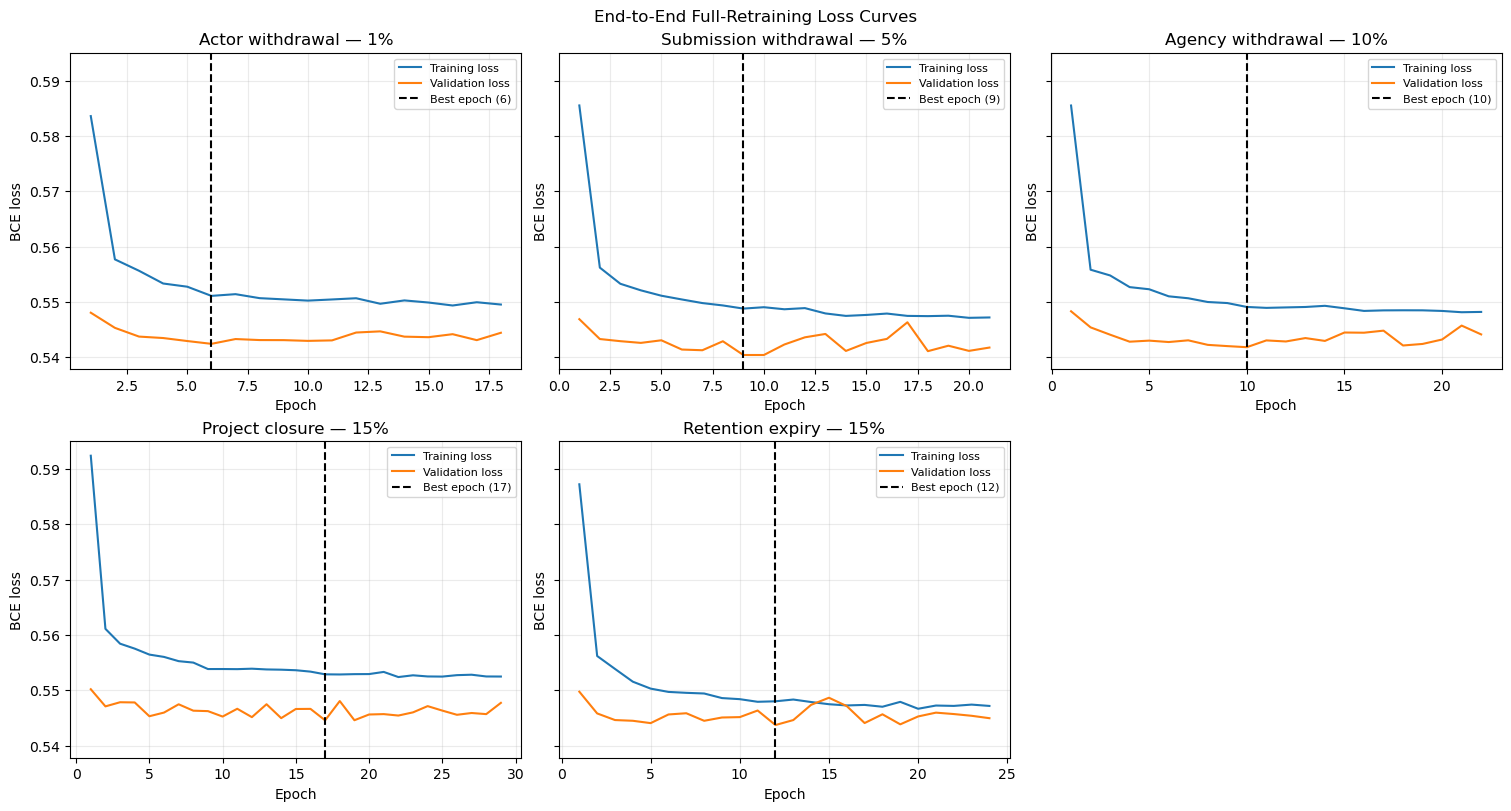

In [28]:
# Create one training-loss chart for each deletion scenario.
loss_figure, loss_axes_grid = plt.subplots(2, 3, figsize=(15, 8), sharey=True, constrained_layout=True)
loss_axes = loss_axes_grid.ravel()
for axis, scenario_name in zip(loss_axes, SCENARIOS):
    history = scenario_runs[scenario_name]["history"]
    best_epoch = scenario_runs[scenario_name]["best_epoch"]
    
    # Plot training and validation loss across epochs.
    axis.plot(history["epoch"], history["train_loss"], label="Training loss")
    axis.plot(history["epoch"], history["validation_loss"], label="Validation loss")
    
    # Mark the epoch whose model weights were retained.
    axis.axvline(best_epoch, color="black", linestyle="--", label=f"Best epoch ({best_epoch})")
    axis.set(title=SCENARIOS[scenario_name]["display_name"], xlabel="Epoch", ylabel="BCE loss")
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)

# Hide the unused sixth chart position.
for axis in loss_axes[len(SCENARIOS):]:
    axis.set_visible(False)
loss_figure.suptitle("End-to-End Full-Retraining Loss Curves")
display(loss_figure)
plt.close(loss_figure)


## 10. Retained-Data Utility Evaluation

### 10.1 Primary Retained-Data Utility After Full Retraining

PR-AUC measures callback detection across thresholds and is especially useful for the positive callback class. AUROC measures general ranking across thresholds. F1 balances callback precision and recall, balanced accuracy gives equal importance to both classes, and BCE measures probability quality.

PR-AUC, AUROC and BCE are threshold-independent. F1 and balanced accuracy use `fixed_baseline_validation_threshold`, loaded from the baseline artifacts and expected to be **0.32**. It is not retuned for individual scenarios, and test data is never used for threshold selection.

In [29]:
# Recreate the baseline architecture and load its saved weights.
baseline_model = CastMeMLP(baseline_checkpoint["input_dim"])
baseline_model.load_state_dict(baseline_checkpoint["state_dict"])

# Move the model to the selected device and prepare it for evaluation.
baseline_model.to(DEVICE).eval()


CastMeMLP(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=16, out_features=8, bias=True)
    (4): ReLU()
    (5): Linear(in_features=8, out_features=1, bias=True)
  )
)

In [30]:
# Evaluate the original and fully retrained models on identical retained test rows.
utility_rows = []
utility_probability_cache = {}
for scenario_name, scenario in SCENARIOS.items():
    data = scenario_data[scenario_name]
    run = scenario_runs[scenario_name]
    # Both models use identical retained test rows for a fair utility comparison.
    retained_test_features = data["retain_test_features"]
    # Process the data using the original baseline preprocessor.
    baseline_processed = baseline_preprocessor.transform(retained_test_features).astype(np.float32)
    original_probabilities = predict(baseline_model, baseline_processed)
    # Use the scenario-specific processing already prepared for the retrained model.
    retrained_probabilities = predict(run["model"], run["prepared"]["retain_test"])
    
    # Keep the probabilities for later comparison and plotting.
    utility_probability_cache[scenario_name] = {
        "original": original_probabilities,
        "retrained": retrained_probabilities,
    }
    # Calculate utility metrics for both models using the same threshold.
    for model_name, probabilities in [
        ("original_baseline", original_probabilities),
        ("full_retraining", retrained_probabilities),
    ]:
        utility_rows.append(
            {
                "scenario": scenario_name,
                "selected_identifier": scenario["identifier"],
                "forget_count": len(data["forget_indices"]),
                "forget_percentage": len(data["forget_indices"]) / len(train_indices),
                "retained_test_count": len(data["retain_test_target"]),
                "evaluation_set_name": "scenario_retained_test",
                "model": model_name,
                "evaluation_threshold": THRESHOLD,
                "threshold_label": "fixed_baseline_validation_threshold",
                "seed": RANDOM_SEED,
                **evaluate_probabilities(data["retain_test_target"], probabilities),
            }
        )
retained_utility_metrics = pd.DataFrame(utility_rows)

# Keep a structured primary artifact with reproducibility fields.
primary_retained_utility_metrics = (
    retained_utility_metrics.query("model == 'full_retraining'")
    [["scenario", "model", "seed", "evaluation_threshold",
      "evaluation_set_name", "retained_test_count", "pr_auc", "auroc",
      "f1", "balanced_accuracy", "binary_cross_entropy"]]
    .rename(columns={
        "model": "model_type",
        "evaluation_threshold": "fixed_threshold",
        "retained_test_count": "evaluation_row_count",
    })
)

# Show only the five primary metrics for the fully retrained models.
primary_retained_utility = primary_retained_utility_metrics[
    ["scenario", "pr_auc", "auroc", "f1",
     "balanced_accuracy", "binary_cross_entropy"]
].rename(columns={
    "scenario": "Scenario",
    "pr_auc": "PR-AUC ↑",
    "auroc": "AUROC ↑",
    "f1": "F1 ↑",
    "balanced_accuracy": "Balanced accuracy ↑",
    "binary_cross_entropy": "BCE ↓",
})
display(primary_retained_utility.style.hide(axis="index").format(precision=4))


Scenario,PR-AUC ↑,AUROC ↑,F1 ↑,Balanced accuracy ↑,BCE ↓
s1_actor_withdrawal,0.6252,0.7678,0.6339,0.6980,0.5474
s2_submission_withdrawal,0.6270,0.7676,0.6344,0.6988,0.5474
s3_agency_withdrawal,0.6315,0.7720,0.6416,0.7026,0.5443
s4_project_closure,0.6380,0.7714,0.6457,0.7021,0.5471
s5_retention_expiry,0.6318,0.7727,0.6358,0.7016,0.5433


In [31]:
# Select the utility metrics to compare.
comparison_metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "specificity",
    "balanced_accuracy",
    "auroc",
    "binary_cross_entropy",
]
difference_rows = []
for scenario_name in SCENARIOS:
    
    # Retrieve both models' results for the same scenario.
    original = retained_utility_metrics.query(
        "scenario == @scenario_name and model == 'original_baseline'"
    ).iloc[0]
    retrained = retained_utility_metrics.query(
        "scenario == @scenario_name and model == 'full_retraining'"
    ).iloc[0]
    
    # Subtract baseline performance from full-retraining performance.
    difference_rows.append(
        {
            "scenario": scenario_name,
            "selected_identifier": SCENARIOS[scenario_name]["identifier"],
            **{
                f"{metric}_difference": retrained[metric] - original[metric]
                for metric in comparison_metrics
            },
        }
    )
retained_utility_differences = pd.DataFrame(difference_rows)

### 10.2 Supplementary Retained-Data Classification Diagnostics

> These values are retained as supporting diagnostics. Accuracy can be influenced by class distribution; precision and recall are jointly summarised by F1; and specificity is already represented alongside recall in balanced accuracy.

In [32]:
# Show the supporting threshold-dependent metrics for full retraining only.
supplementary_retained_diagnostics = (
    retained_utility_metrics.query("model == 'full_retraining'")
    [["scenario", "accuracy", "precision", "recall", "specificity"]]
    .rename(columns={
        "scenario": "Scenario",
        "accuracy": "Accuracy",
        "precision": "Precision",
        "recall": "Recall",
        "specificity": "Specificity",
    })
)
display(supplementary_retained_diagnostics.style.hide(axis="index").format(precision=4))


Scenario,Accuracy,Precision,Recall,Specificity
s1_actor_withdrawal,0.6794,0.5408,0.7656,0.6303
s2_submission_withdrawal,0.6810,0.5427,0.7633,0.6342
s3_agency_withdrawal,0.6789,0.5404,0.7895,0.6156
s4_project_closure,0.6795,0.5463,0.7892,0.6150
s5_retention_expiry,0.6869,0.5490,0.7550,0.6482


In [33]:
# Compare both models on test records that match each deletion rule.
matched_rows = []
for scenario_name in SCENARIOS:
    data, run = scenario_data[scenario_name], scenario_runs[scenario_name]
    
    # Generate predictions from the original baseline model.
    original = predict(baseline_model, baseline_preprocessor.transform(data["matched_test_features"]).astype(np.float32))
    
    # Generate predictions from the fully retrained model.
    retrained = predict(run["model"], run["prepared"]["matched_test"])
    
    # Record how much the two models' predictions differ.
    matched_rows.append({
        "scenario": scenario_name, "matched_test_rows": len(data["matched_test_target"]),
        "original_mean_probability": original.mean(), "retrained_mean_probability": retrained.mean(),
        "mean_absolute_probability_difference": np.abs(original - retrained).mean(),
        "prediction_disagreement_rate": ((original >= THRESHOLD) != (retrained >= THRESHOLD)).mean(),
    })
matched_test_behaviour = pd.DataFrame(matched_rows)


### 10.3 Supporting Retained-Data Figures

The ROC curves and confusion matrices are supporting visual diagnostics. Confusion matrices use consistent axes, labels and colour scaling across all five seed-42 full-retraining models.

#### Retained-Test ROC Curves

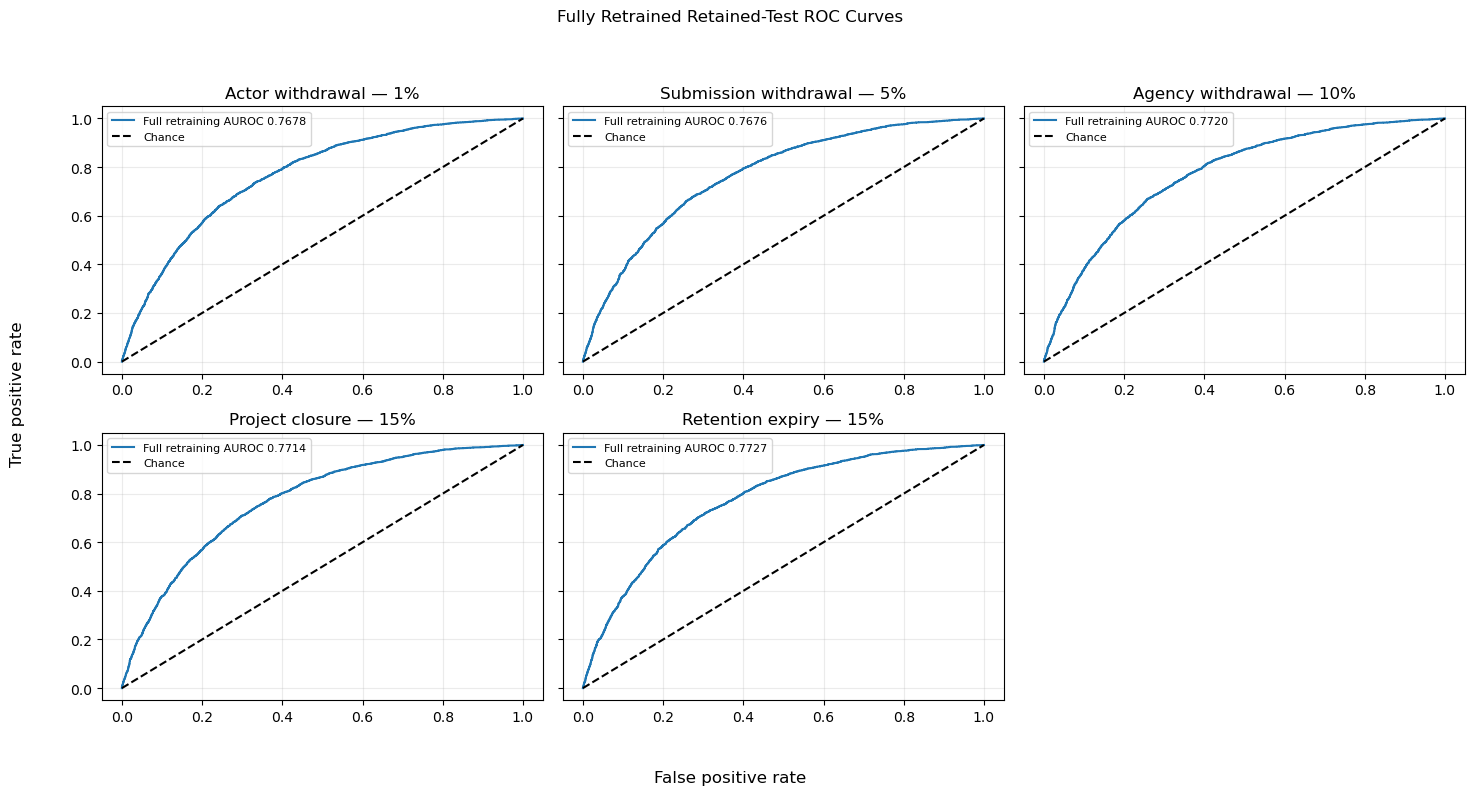

In [34]:
# Create one ROC comparison chart for each deletion scenario.
roc_figure, roc_axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
roc_axes = np.asarray(roc_axes).ravel()
for axis, scenario_name in zip(roc_axes, SCENARIOS):
    data = scenario_data[scenario_name]
    probabilities = utility_probability_cache[scenario_name]["retrained"]
    false_positive_rate, true_positive_rate, _ = roc_curve(
        data["retain_test_target"], probabilities
    )
    axis.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"Full retraining AUROC {roc_auc_score(data['retain_test_target'], probabilities):.4f}",
    )
    # Add the performance expected from random guessing.
    axis.plot([0, 1], [0, 1], "k--", label="Chance")
    axis.set(title=SCENARIOS[scenario_name]["display_name"])
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)

# Hide the unused sixth chart position.
for axis in roc_axes[len(SCENARIOS):]:
    axis.set_visible(False)
roc_figure.suptitle("Fully Retrained Retained-Test ROC Curves")
roc_figure.supxlabel("False positive rate")
roc_figure.supylabel("True positive rate")
roc_figure.tight_layout(rect=(0.03, 0.03, 1, 0.94))
display(roc_figure)
plt.close(roc_figure)

#### Retained-Test Confusion Matrices

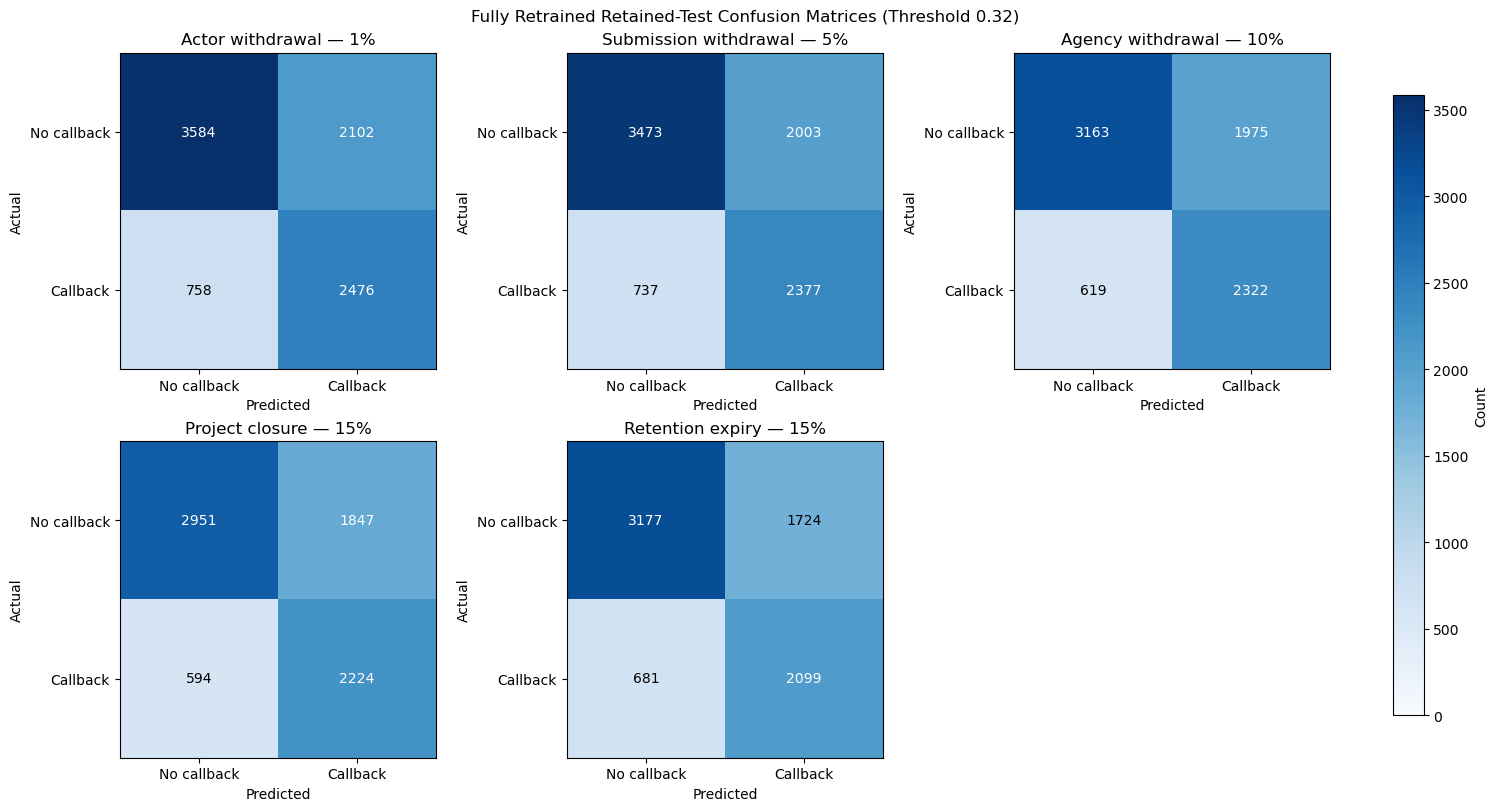

In [35]:
# Extract each retrained model's retained-test confusion matrix.
confusion_matrices = {
    scenario_name: np.asarray(
        retained_utility_metrics.query(
            "scenario == @scenario_name and model == 'full_retraining'"
        ).iloc[0]["confusion_matrix"]
    )
    for scenario_name in SCENARIOS
}
# Use one colour scale so counts can be compared across scenarios.
common_vmax = max(matrix.max() for matrix in confusion_matrices.values())
confusion_figure, confusion_axes = plt.subplots(
    2, 3, figsize=(15, 8), constrained_layout=True
)
confusion_axes = np.asarray(confusion_axes).ravel()

# Display the confusion matrix as a colour-coded chart.
colour_image = None
for axis, scenario_name in zip(confusion_axes, SCENARIOS):
    matrix = confusion_matrices[scenario_name]
    colour_image = axis.imshow(matrix, cmap="Blues", vmin=0, vmax=common_vmax)
    axis.set(
        title=SCENARIOS[scenario_name]["display_name"],
        xlabel="Predicted",
        ylabel="Actual",
        xticks=[0, 1],
        xticklabels=["No callback", "Callback"],
        yticks=[0, 1],
        yticklabels=["No callback", "Callback"],
    )
    # Write each prediction count inside its square.
    for row in range(2):
        for column in range(2):
            colour = "white" if matrix[row, column] > common_vmax / 2 else "black"
            axis.text(column, row, matrix[row, column], ha="center", va="center", color=colour)

# Hide the unused sixth chart position.
for axis in confusion_axes[len(SCENARIOS):]:
    axis.set_visible(False)

# Add one shared colour bar for every scenario.
confusion_figure.colorbar(colour_image, ax=confusion_axes, label="Count", shrink=0.88)
confusion_figure.suptitle(
    f"Fully Retrained Retained-Test Confusion Matrices (Threshold {THRESHOLD:.2f})"
)
display(confusion_figure)
plt.close(confusion_figure)


## 11. Forget-Set Behavioural Reference

Mean absolute probability change measures how much callback probabilities changed after full retraining. Prediction disagreement is the proportion of deleted records whose binary prediction changed. These are behavioural diagnostics, not independent proof of forgetting. Full retraining provides the reference behaviour for later approximate-unlearning comparisons.

In [36]:
# Compare the Original Model and full retraining on deleted training records.
forget_rows = []
for scenario_name in SCENARIOS:
    data, run = scenario_data[scenario_name], scenario_runs[scenario_name]
    original = predict(
        baseline_model,
        baseline_preprocessor.transform(data["forget_features"]).astype(np.float32),
    )
    retrained = predict(run["model"], run["prepared"]["forget"])
    original_metrics = evaluate_probabilities(data["forget_target"], original)
    retrained_metrics = evaluate_probabilities(data["forget_target"], retrained)
    forget_rows.append({
        "scenario": scenario_name, "forget_rows": len(data["forget_target"]),
        "original_mean_probability": original.mean(),
        "retrained_mean_probability": retrained.mean(),
        "mean_absolute_probability_difference": np.abs(original - retrained).mean(),
        "prediction_disagreement_rate": ((original >= THRESHOLD) != (retrained >= THRESHOLD)).mean(),
        "original_bce_loss": original_metrics["binary_cross_entropy"],
        "retrained_bce_loss": retrained_metrics["binary_cross_entropy"],
        "original_accuracy": original_metrics["accuracy"],
        "retrained_accuracy": retrained_metrics["accuracy"],
    })
forget_set_behaviour = pd.DataFrame(forget_rows)
forget_set_reference = forget_set_behaviour[
    ["scenario", "mean_absolute_probability_difference", "prediction_disagreement_rate"]
].rename(columns={
    "scenario": "Scenario",
    "mean_absolute_probability_difference": "Mean absolute probability change",
    "prediction_disagreement_rate": "Prediction disagreement rate",
})
display(forget_set_reference.style.hide(axis="index").format(precision=4))


Scenario,Mean absolute probability change,Prediction disagreement rate
s1_actor_withdrawal,0.0104,0.0145
s2_submission_withdrawal,0.0168,0.0309
s3_agency_withdrawal,0.0168,0.0405
s4_project_closure,0.0168,0.0269
s5_retention_expiry,0.0191,0.0319


### 11.1 Supplementary Forget-Set Diagnostics

Deleted training records are the actual forget sets. Scenario-matched test records are unseen records associated with the same deletion rule. Their probability, BCE and accuracy results remain supporting diagnostics; low accuracy, high BCE or changed predictions do not directly prove forgetting.

In [37]:
# Keep detailed forget-set and matched-test measurements supplementary.
display(forget_set_behaviour.style.hide(axis="index").format(precision=4))
display(matched_test_behaviour.style.hide(axis="index").format(precision=4))

# Select the main characteristics needed to interpret each scenario.
scenario_context_table = scenario_summary[
    ["display_name", "achieved_percentage", "forget_callback_rate", "profile_distance"]
].rename(columns={
    "display_name": "scenario",
    "achieved_percentage": "achieved_deletion_percentage",
})
# Display the scenario size, callback balance and feature difference.
display(
    scenario_context_table.style.hide(axis="index").format({
        "achieved_deletion_percentage": "{:.2%}",
        "forget_callback_rate": "{:.2%}",
        "profile_distance": "{:.4f}",
    })
)


scenario,forget_rows,original_mean_probability,retrained_mean_probability,mean_absolute_probability_difference,prediction_disagreement_rate,original_bce_loss,retrained_bce_loss,original_accuracy,retrained_accuracy
s1_actor_withdrawal,415,0.2006,0.1928,0.0104,0.0145,0.4302,0.4313,0.7807,0.7855
s2_submission_withdrawal,2137,0.3704,0.3572,0.0168,0.0309,0.5608,0.5628,0.6635,0.6673
s3_agency_withdrawal,4224,0.3325,0.3297,0.0168,0.0405,0.5460,0.5477,0.6705,0.6716
s4_project_closure,6289,0.3205,0.3175,0.0168,0.0269,0.5210,0.5221,0.6831,0.6883
s5_retention_expiry,6298,0.3673,0.3522,0.0191,0.0319,0.5524,0.5533,0.6732,0.6807


scenario,matched_test_rows,original_mean_probability,retrained_mean_probability,mean_absolute_probability_difference,prediction_disagreement_rate
s1_actor_withdrawal,80,0.1992,0.1912,0.0116,0.0000
s2_submission_withdrawal,410,0.3476,0.3359,0.0149,0.0317
s3_agency_withdrawal,921,0.3385,0.3357,0.0177,0.0282
s4_project_closure,1384,0.3199,0.3178,0.0164,0.0267
s5_retention_expiry,1319,0.3586,0.3442,0.0191,0.0281


scenario,achieved_deletion_percentage,forget_callback_rate,profile_distance
Actor withdrawal — 1%,0.99%,18.07%,1.6180
Submission withdrawal — 5%,5.09%,37.81%,0.0578
Agency withdrawal — 10%,10.06%,32.88%,0.8949
Project closure — 15%,14.97%,30.66%,0.3365
Retention expiry — 15%,15.00%,36.58%,0.0499


## 12. Scenario Interpretation

- These are descriptive single-seed reference comparisons, not statistical inference.
- Interpret results jointly with deletion size, request structure, callback prevalence, feature-profile distance, entity coverage, overlap and repeated-round composition.
- Scenario differences cannot be attributed solely to deletion percentage.
- Project closure and retention expiry are deliberately similar in size, making their different subset structures especially informative.


## 13. Save Outputs

In [38]:
# Define the folders used to save each type of full-retraining artifact.
OUTPUT_DIRS = {
    name: FULL_RESULTS_ROOT / name
    for name in [
        "configuration",
        "forget_indices",
        "retain_indices",
        "histories",
        "metrics",
        "tables",
        "figures",
    ]
}
# Create the result and model folders if they do not already exist.
for directory in [*OUTPUT_DIRS.values(), FULL_MODEL_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)


In [39]:
# Convert profile values into standard JSON-compatible Python types.
profile_statistics = {
    name: json.loads(pd.DataFrame([profile]).to_json(orient="records"))[0]
    for name, profile in SCENARIO_PROFILES.items()
}
# Prepare the main statistics for each deletion scenario.
scenario_statistics = []
for row in scenario_summary.to_dict(orient="records"):
    scenario_name = row["scenario"]
    data = scenario_data[scenario_name]
    scenario_statistics.append(
        {
            "scenario_name": scenario_name,
            "entity_column": row["entity_column"],
            "subset_rule": row["subset_rule"],
            "identifier": row["selected_identifier"],
            "deletion_reason": row["deletion_reason"],
            "requested_percentage": row["requested_percentage"],
            "achieved_percentage": row["achieved_percentage"],
            "target_forget_count": int(row["target_forget_count"]),
            "actual_forget_count": int(row["actual_forget_count"]),
            "retain_count": int(row["retain_count"]),
            "row_count_difference": int(row["row_count_difference"]),
            "percentage_point_difference": row["percentage_point_difference"],
            "forget_callback_rate": row["forget_callback_rate"],
            "retain_callback_rate": row["retain_callback_rate"],
            "forget_index_hash": array_hash(data["forget_indices"]),
            "retain_index_hash": array_hash(data["retain_indices"]),
            "actors": int(row["actors"]),
            "managers": int(row["managers"]),
            "films": int(row["films"]),
            "roles": int(row["roles"]),
            "dates": int(row["dates"]),
            "repeated_actor_role_pairs": int(row["repeated_actor_role_pairs"]),
            "profile_distance": row["profile_distance"],
        }
    )


In [40]:
# Record the dataset, experiment settings and deletion scenario definitions.
manifest = {
    "dataset_description": "Synthetic repeated-round personal audition submissions with audit-only deletion metadata.",
    "audit_metadata_definitions": {
        "audition_date": "ISO audition date used only for retention-based deletion",
        "withdrawal_requested": "Recorded submission-level withdrawal request used only for deletion construction",
    },
    "feature_order": FEATURE_COLUMNS,
    "excluded_metadata_columns": METADATA_COLUMNS,
    "target_column": TARGET_COLUMN,
    "split_strategy": "seed-42 two-stage stratified random row split",
    "split_proportions": {"train": 0.70, "validation": 0.15, "test": 0.15},
    "baseline_split_artifacts": baseline_manifest["split_artifacts"],
    "seed": RANDOM_SEED, "threshold": THRESHOLD,
    "threshold_label": "fixed_baseline_validation_threshold",
    "threshold_selection_split": "baseline_validation",
    "architecture": ARCHITECTURE, "hyperparameters": HYPERPARAMETERS,
    "preprocessing_strategy": "refit_on_retain_training_only",
    "selected_actor_id": ACTOR_IDENTIFIER, "manager_id": MANAGER_IDENTIFIER,
    "film_id": FILM_IDENTIFIER, "retention_cutoff": RETENTION_CUTOFF,
    
    # Record package versions to describe the execution environment.
    "runtime_versions": {
        "python": platform.python_version(), "pandas": pd.__version__,
        "pytorch": torch.__version__, "scikit_learn": sklearn.__version__,
    },
    "raw_dataset_hash": RAW_CSV_HASH, "cleaned_dataset_hash": CLEANED_CSV_HASH,
    "baseline_model_path": str(BASELINE_MODEL_PATH.relative_to(CODE_ROOT)),
    "baseline_model_hash": sha256(BASELINE_MODEL_PATH),
    "baseline_preprocessor_path": str(BASELINE_PREPROCESSOR_PATH.relative_to(CODE_ROOT)),
    "baseline_preprocessor_hash": sha256(BASELINE_PREPROCESSOR_PATH),
    "scenarios": SCENARIOS, "scenario_statistics": scenario_statistics,
    "profile_statistics": profile_statistics,
    "scenario_overlap": json.loads(scenario_overlap.to_json(orient="records")),
    "result_table_paths": {
        "scenario_reproducibility_summary": str((OUTPUT_DIRS["tables"] / "scenario_reproducibility_summary.csv").relative_to(CODE_ROOT)),
        "primary_retained_utility_metrics": str((OUTPUT_DIRS["metrics"] / "primary_retained_utility_metrics.csv").relative_to(CODE_ROOT)),
        "supplementary_retained_classification_diagnostics": str((OUTPUT_DIRS["metrics"] / "supplementary_retained_classification_diagnostics.csv").relative_to(CODE_ROOT)),
        "forget_set_behavioural_reference": str((OUTPUT_DIRS["metrics"] / "forget_set_behavioural_reference.csv").relative_to(CODE_ROOT)),
    },
    "canonical_reference_statement": "Full retraining is a fixed-seed reference, not proof of regulatory compliance.",
}
MANIFEST_PATH = OUTPUT_DIRS["configuration"] / "scenario_manifest.json"
MANIFEST_PATH.write_text(json.dumps(manifest, indent=2))


16620

In [41]:
# Save the supporting artifacts for each deletion scenario.
for scenario_name in SCENARIOS:
    data, run = scenario_data[scenario_name], scenario_runs[scenario_name]
    # Save the exact training rows assigned to the forget and retain sets.
    np.save(OUTPUT_DIRS["forget_indices"] / f"{scenario_name}_forget_train_indices.npy", data["forget_indices"])
    np.save(OUTPUT_DIRS["retain_indices"] / f"{scenario_name}_retain_train_indices.npy", data["retain_indices"])
    
    # Save the training and validation loss recorded across epochs.
    run["history"].to_csv(OUTPUT_DIRS["histories"] / f"{scenario_name}_training_history.csv", index=False)
    
    # Save the retain-fitted preprocessor inside the scenario's model folder.
    model_dir = FULL_MODEL_ROOT / scenario_name
    model_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(run["preprocessor"], model_dir / "preprocessor.joblib")


In [42]:
def full_checkpoint_payload(scenario_name: str) -> dict[str, object]:
    scenario, data, run = SCENARIOS[scenario_name], scenario_data[scenario_name], scenario_runs[scenario_name]
    preprocessor_path = FULL_MODEL_ROOT / scenario_name / "preprocessor.joblib"
    
    # Move model weights to the CPU so the checkpoint is device-portable.
    cpu_state = {key: value.detach().cpu().clone() for key, value in run["model"].state_dict().items()}
    
    # Store the model weights, scenario details and training configuration.
    return {
        "state_dict": cpu_state, "scenario": scenario_name,
        "selected_identifier": scenario["identifier"], "subset_rule": scenario["subset_rule"],
        "requested_percentage": scenario["requested_percentage"],
        "achieved_percentage": len(data["forget_indices"]) / len(train_indices),
        "selected_actor_id": ACTOR_IDENTIFIER, "manager_id": MANAGER_IDENTIFIER,
        "film_id": FILM_IDENTIFIER, "retention_cutoff": RETENTION_CUTOFF,
        "forget_count": len(data["forget_indices"]), "retain_count": len(data["retain_indices"]),
        "input_dim": len(FEATURE_COLUMNS), "feature_columns": FEATURE_COLUMNS,
        "architecture": ARCHITECTURE, "hyperparameters": HYPERPARAMETERS,
        "threshold": THRESHOLD, "threshold_label": "fixed_baseline_validation_threshold",
        "seed": RANDOM_SEED, "best_epoch": run["best_epoch"], "stopping_epoch": run["epochs_completed"],
        "best_validation_loss": run["best_validation_loss"], "early_stopping": run["early_stopping"],
        
        # Record the software versions used to train the model.
        "runtime_versions": {"python": platform.python_version(), "pytorch": torch.__version__,
                             "scikit_learn": sklearn.__version__},
        
        # Store hashes to verify the datasets, indices and preprocessor later.
        "raw_csv_hash": RAW_CSV_HASH, "cleaned_csv_hash": CLEANED_CSV_HASH,
        "forget_index_hash": array_hash(data["forget_indices"]),
        "retain_index_hash": array_hash(data["retain_indices"]),
        "preprocessing_strategy": "refit_on_retain_training_only",
        "preprocessor_path": str(preprocessor_path.relative_to(CODE_ROOT)),
        "preprocessor_hash": sha256(preprocessor_path),
    }


In [43]:
# Save one complete model checkpoint for each deletion scenario.
for scenario_name in SCENARIOS:
    torch.save(full_checkpoint_payload(scenario_name), FULL_MODEL_ROOT / scenario_name / "model.pt")


In [44]:
# Save the primary and supplementary result tables in one place.
scenario_summary.to_csv(OUTPUT_DIRS["tables"] / "scenario_summary.csv", index=False)
scenario_reproducibility_summary.to_csv(
    OUTPUT_DIRS["tables"] / "scenario_reproducibility_summary.csv", index=False
)
scenario_overlap.to_csv(OUTPUT_DIRS["tables"] / "scenario_overlap.csv", index=False)
training_summary.to_csv(OUTPUT_DIRS["tables"] / "training_summary.csv", index=False)
primary_retained_utility_metrics.to_csv(
    OUTPUT_DIRS["metrics"] / "primary_retained_utility_metrics.csv", index=False
)
supplementary_retained_diagnostics.to_csv(
    OUTPUT_DIRS["metrics"] / "supplementary_retained_classification_diagnostics.csv", index=False
)
forget_set_reference.to_csv(
    OUTPUT_DIRS["metrics"] / "forget_set_behavioural_reference.csv", index=False
)
retained_utility_metrics.to_csv(
    OUTPUT_DIRS["metrics"] / "retained_utility_metrics.csv",
    index=False,
)
# Save the utility and forget-set evaluation metrics.
retained_utility_differences.to_csv(
    OUTPUT_DIRS["metrics"] / "retained_utility_differences.csv",
    index=False,
)
forget_set_behaviour.to_csv(
    OUTPUT_DIRS["metrics"] / "forget_set_behaviour.csv",
    index=False,
)
matched_test_behaviour.to_csv(
    OUTPUT_DIRS["metrics"] / "scenario_matched_test_behaviour.csv",
    index=False,
)
# Save the figures as high-resolution PNG files.
loss_figure.savefig(
    OUTPUT_DIRS["figures"] / "combined_loss_curves.png",
    dpi=300,
    bbox_inches="tight",
)
roc_figure.savefig(
    OUTPUT_DIRS["figures"] / "retained_test_roc_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
confusion_figure.savefig(
    OUTPUT_DIRS["figures"] / "retrained_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight",
)
print("Saved configured full-retraining artifacts.")


Saved configured full-retraining artifacts.


## 14. Reload and Verify Saved Artifacts

In [45]:
def assert_saved_numeric_table(file_path: Path, expected: pd.DataFrame) -> None:
    """Reload one table and compare every numeric column to its in-memory source."""
    
    # Reload the table from disk.
    saved = pd.read_csv(file_path)
    
    # Confirm that its structure has not changed.
    assert saved.columns.tolist() == expected.columns.tolist()
    assert len(saved) == len(expected)
    
    # Compare every numerical column with the original values.
    for column in expected.columns:
        if pd.api.types.is_numeric_dtype(expected[column]):
            assert np.allclose(saved[column].to_numpy(), expected[column].to_numpy())
    return None


# List all result tables that must be checked.
TABLES_TO_VERIFY = {
    OUTPUT_DIRS["tables"] / "scenario_summary.csv": scenario_summary,
    OUTPUT_DIRS["tables"] / "scenario_reproducibility_summary.csv": scenario_reproducibility_summary,
    OUTPUT_DIRS["tables"] / "scenario_overlap.csv": scenario_overlap,
    OUTPUT_DIRS["tables"] / "training_summary.csv": training_summary,
    OUTPUT_DIRS["metrics"] / "primary_retained_utility_metrics.csv": primary_retained_utility_metrics,
    OUTPUT_DIRS["metrics"] / "supplementary_retained_classification_diagnostics.csv": supplementary_retained_diagnostics,
    OUTPUT_DIRS["metrics"] / "forget_set_behavioural_reference.csv": forget_set_reference,
    OUTPUT_DIRS["metrics"] / "retained_utility_metrics.csv": retained_utility_metrics,
    OUTPUT_DIRS["metrics"] / "retained_utility_differences.csv": retained_utility_differences,
    OUTPUT_DIRS["metrics"] / "forget_set_behaviour.csv": forget_set_behaviour,
    OUTPUT_DIRS["metrics"] / "scenario_matched_test_behaviour.csv": matched_test_behaviour,
}
# Reload and verify every saved table.
for table_path, frame in TABLES_TO_VERIFY.items():
    assert_saved_numeric_table(table_path, frame)

In [46]:
# Reload the saved manifest and confirm it matches the in-memory version.
saved_manifest = json.loads(MANIFEST_PATH.read_text())
assert saved_manifest == manifest

# Check the fixed scenario identifiers and dataset hashes.
assert saved_manifest["selected_actor_id"] == ACTOR_IDENTIFIER
assert saved_manifest["manager_id"] == MANAGER_IDENTIFIER
assert saved_manifest["film_id"] == FILM_IDENTIFIER
assert saved_manifest["retention_cutoff"] == RETENTION_CUTOFF
assert saved_manifest["raw_dataset_hash"] == RAW_CSV_HASH
assert saved_manifest["cleaned_dataset_hash"] == CLEANED_CSV_HASH

# Confirm the fixed seed and baseline-selected threshold.
assert saved_manifest["seed"] == RANDOM_SEED == 42
assert saved_manifest["threshold"] == THRESHOLD == 0.32
assert saved_manifest["threshold_label"] == "fixed_baseline_validation_threshold"

# Confirm that all scenario statistics were saved correctly.
assert saved_manifest["scenario_statistics"] == scenario_statistics

saved_statistics_by_name = {
    row["scenario_name"]: row for row in saved_manifest["scenario_statistics"]
}
assert set(saved_statistics_by_name) == set(SCENARIOS)

# Check the main saved fields for every scenario individually.
for expected in scenario_statistics:
    saved = saved_statistics_by_name[expected["scenario_name"]]
    for key in [
        "scenario_name", "entity_column", "identifier", "subset_rule", "deletion_reason",
        "requested_percentage", "achieved_percentage", "target_forget_count",
        "actual_forget_count", "retain_count", "row_count_difference",
        "percentage_point_difference", "forget_callback_rate", "retain_callback_rate",
        "forget_index_hash", "retain_index_hash",
    ]:
        assert saved[key] == expected[key]


In [47]:
# Reload every scenario's saved indices, history, model and preprocessor.
reloaded_artifacts = {}
for name in SCENARIOS:
    data, run = scenario_data[name], scenario_runs[name]
    saved_forget = np.load(OUTPUT_DIRS["forget_indices"] / f"{name}_forget_train_indices.npy")
    saved_retain = np.load(OUTPUT_DIRS["retain_indices"] / f"{name}_retain_train_indices.npy")
    
    # Confirm that the saved training history matches the original.
    assert_saved_numeric_table(OUTPUT_DIRS["histories"] / f"{name}_training_history.csv", run["history"])
    
    # Reload the model checkpoint and scenario-specific preprocessor.
    checkpoint = torch.load(FULL_MODEL_ROOT / name / "model.pt", map_location="cpu", weights_only=False)
    preprocessor = joblib.load(FULL_MODEL_ROOT / name / "preprocessor.joblib")
    
    # Confirm that the saved row indices are unchanged.
    assert np.array_equal(saved_forget, data["forget_indices"])
    assert np.array_equal(saved_retain, data["retain_indices"])
    
    # Verify the scenario and integrity information in the checkpoint.
    assert checkpoint["selected_identifier"] == SCENARIOS[name]["identifier"]
    assert checkpoint["subset_rule"] == SCENARIOS[name]["subset_rule"]
    assert checkpoint["preprocessor_hash"] == sha256(FULL_MODEL_ROOT / name / "preprocessor.joblib")
    assert checkpoint["forget_index_hash"] == array_hash(saved_forget)
    assert checkpoint["retain_index_hash"] == array_hash(saved_retain)
    
    # Confirm that the saved feature configuration is correct.
    assert checkpoint["feature_columns"] == FEATURE_COLUMNS and checkpoint["input_dim"] == len(FEATURE_COLUMNS)
    assert preprocessor.get_feature_names_out().tolist() == CONTINUOUS_COLUMNS + BINARY_COLUMNS
    
    # Keep the verified artifacts for prediction checks.
    reloaded_artifacts[name] = (checkpoint, preprocessor)


In [48]:
# Confirm that every reloaded model produces valid and unchanged predictions.
for name, (checkpoint, preprocessor) in reloaded_artifacts.items():
    data, run = scenario_data[name], scenario_runs[name]
    
    # Recreate the model and load its saved weights on the CPU.
    portable_model = CastMeMLP(checkpoint["input_dim"])
    portable_model.load_state_dict(checkpoint["state_dict"]); portable_model.eval()
    
    # Check that the model produces valid outputs for a small sample.
    sample = preprocessor.transform(data["retain_features"].iloc[:8]).astype(np.float32)
    with torch.no_grad():
        assert torch.isfinite(portable_model(torch.tensor(sample))).all()
    
    # Move the model to the selected device for the prediction comparison.
    portable_model = portable_model.to(DEVICE)
    
    # Compare predictions from the original and reloaded artifacts.
    expected = predict(run["model"], run["prepared"]["retain_test"][:16])
    reloaded = preprocessor.transform(data["retain_test_features"].iloc[:16]).astype(np.float32)
    assert np.allclose(predict(portable_model, reloaded), expected)


In [49]:
# Confirm that the raw and cleaned datasets still have their original hashes.
assert sha256(RAW_DATA_PATH) == RAW_CSV_HASH and sha256(CLEAN_DATA_PATH) == CLEANED_CSV_HASH

# Recalculate the hashes of every protected baseline artifact.
current_hashes = {str(path.relative_to(CODE_ROOT)): sha256(path) for path in BASELINE_ARTIFACTS}

# Record any files whose hashes changed during full retraining.
mismatches = {path: {"before": BASELINE_HASHES[path], "after": current_hashes[path]}
              for path in BASELINE_HASHES if current_hashes[path] != BASELINE_HASHES[path]}

# Fail if any protected baseline artifact was modified.
assert not mismatches, mismatches
print("All full-retraining artifacts reloaded; datasets and baseline artifacts are unchanged.")


All full-retraining artifacts reloaded; datasets and baseline artifacts are unchanged.


## 15. Summary

- Five realistic deletion scenarios were constructed from the fixed seed-42 training split.
- Each scenario partitions the same training data into verified, disjoint forget and retain sets.
- One fresh full-retraining reference model was trained per scenario using retained rows only.
- Retained validation rows controlled early stopping; test and forget rows did not affect training.
- PR-AUC, AUROC and BCE assess probability quality independently of the classification threshold.
- F1 and balanced accuracy use the baseline-selected threshold of 0.32 without retuning.
- Forget-set probability change and disagreement are behavioural diagnostics, not proof of erasure.
- Scenario results must be interpreted jointly with deletion size, composition and callback rate.
- Saved models, preprocessors, indices, tables and figures were reloaded and verified.
- The raw data, cleaned data and protected baseline artifacts remained unchanged.

In [50]:
assert len(SCENARIOS) == 5
assert training_summary["seed"].eq(42).all()
assert primary_retained_utility_metrics["fixed_threshold"].eq(0.32).all()